# Previsao do Fluxo de Radio Solar (F10.7) - Machine Learning

Global Solution

**Integrantes**
Felipe Piccolo - RM569324
Leonardo Bueno - RM572152
João Vitor Veiga - RM569874

**Problema:** prever o fluxo de radio solar de 10,7 cm (F10.7) a partir de outros indices
de atividade solar (manchas, area de manchas, novas regioes, flares).

O F10.7 e o principal indicador usado para estimar o arrasto atmosferico sobre satelites:
quando a atividade solar sobe, a alta atmosfera se expande e satelites em orbita baixa
perdem altitude mais rapido. Prever esse indice tem aplicacao direta na operacao de
constelacoes de satelites (ex: Starlink), o que conecta o trabalho com a nova economia espacial.

Como o alvo e um valor numerico continuo, este e um problema de **regressao**.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (8, 5)

## 2. Carregar os dados

Dataset: Space Weather - Solar + Geomagnetic Indices (Kaggle).
Aqui usamos o arquivo `daily_solar_data.csv`.

In [2]:
df = pd.read_csv('daily_solar_data.csv')
df.head()

,Date,Radio Flux 10.7cm,Sunspot Number,Sunspot Area (10^6 Hemis.),New Regions,Stanford Mean Solar Field (GOES15),Stanford Background X-Ray Flux,Flares: C,Flares: M,Flares: X,Flares: S,Flares: 1,Flares: 2,Flares: 3
0,1997-01-01,72,0,0,0,*,A0.5,0,0,0,-1,-1,-1,-1
1,1997-01-02,72,0,0,0,*,A0.5,0,0,0,-1,-1,-1,-1
2,1997-01-03,73,0,0,0,3,A0.5,0,0,0,-1,-1,-1,-1
3,1997-01-04,74,13,10,1,*,A0.6,0,0,0,-1,-1,-1,-1
4,1997-01-05,74,15,20,0,5,A0.7,0,0,0,-1,-1,-1,-1


## 3. Conhecendo o dataset

Antes de modelar, precisamos entender o que cada coluna representa e quais sao numericas.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10330 entries, 0 to 10329
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Date                                10330 non-null  object
 1   Radio Flux 10.7cm                   10330 non-null  int64 
 2   Sunspot Number                      10330 non-null  int64 
 3   Sunspot Area (10^6 Hemis.)          10330 non-null  int64 
 4   New Regions                         10330 non-null  int64 
 5   Stanford Mean Solar Field (GOES15)  10330 non-null  object
 6   Stanford Background X-Ray Flux      10330 non-null  object
 7   Flares: C                           10330 non-null  int64 
 8   Flares: M                           10330 non-null  int64 
 9   Flares: X                           10330 non-null  int64 
 10  Flares: S                           10330 non-null  int64 
 11  Flares: 1                           10330 non-null  in

In [4]:
df.describe()

,Radio Flux 10.7cm,Sunspot Number,Sunspot Area (10^6 Hemis.),New Regions,Flares: C,Flares: M,Flares: X,Flares: S,Flares: 1,Flares: 2,Flares: 3
count,10330.000000,10330.000000,10330.000000,10330.000000,10330.000000,10330.000000,10330.000000,10330.000000,10330.000000,10330.000000,10330.000000
mean,107.924298,64.940852,443.630300,0.540271,2.552662,0.270668,0.019458,3.237367,0.212391,0.035624,-0.003291
std,41.352475,64.309388,549.007628,0.841934,3.763611,0.839139,0.157766,5.530104,0.636607,0.258253,0.119657
min,64.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,73.000000,12.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,94.000000,47.000000,247.500000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,134.000000,104.000000,670.000000,1.000000,4.000000,0.000000,0.000000,4.000000,0.000000,0.000000,0.000000
max,343.000000,401.000000,5690.000000,6.000000,30.000000,12.000000,3.000000,55.000000,7.000000,4.000000,2.000000


Descricao das variaveis:

- `Date`: data da medicao (diaria, de 1997 a 2024)
- `Radio Flux 10.7cm`: fluxo de radio solar em 10,7 cm -> **alvo**
- `Sunspot Number`: numero de manchas solares
- `Sunspot Area (10^6 Hemis.)`: area total coberta por manchas
- `New Regions`: numero de novas regioes ativas surgidas no dia
- `Stanford Mean Solar Field (GOES15)`: campo magnetico solar medio
- `Stanford Background X-Ray Flux`: classe de fluxo de raios-X de fundo (ex: A0.5, B1.3)
- `Flares: C / M / X / S / 1 / 2 / 3`: contagem de flares por classe/tipo

## 4. Tratamento de dados

O `isna()` nao acusa nulos, mas o dataset usa marcadores de ausencia:

- `*` aparece em colunas de texto onde nao houve medicao
- `-1` aparece nas colunas de flares como valor "sem dado"

Precisamos converter esses marcadores em `NaN` de verdade antes de seguir.

In [5]:
# Stanford Mean Solar Field vem como texto por causa do '*'
# convertendo para numero (o que nao for numero vira NaN)
df['Stanford Mean Solar Field (GOES15)'] = pd.to_numeric(
    df['Stanford Mean Solar Field (GOES15)'], errors='coerce'
)

# -1 nas colunas de flares e marcador de ausencia
flare_cols = ['Flares: C', 'Flares: M', 'Flares: X',
              'Flares: S', 'Flares: 1', 'Flares: 2', 'Flares: 3']
for c in flare_cols:
    df.loc[df[c] == -1, c] = np.nan

A coluna `Stanford Background X-Ray Flux` e um codigo de classe (A0.5, B1.3...) e tem
muitos valores ausentes (`*`). Como ja temos varios indices numericos com boa relacao
com o alvo, vamos remove-la em vez de tentar codifica-la. Tambem removemos `Date`,
porque aqui estamos tratando o problema como tabular (holdout), nao como serie temporal.

In [6]:
df = df.drop(columns=['Stanford Background X-Ray Flux', 'Date'])

print('nulos por coluna:')
print(df.isna().sum())

nulos por coluna:
Radio Flux 10.7cm                      0
Sunspot Number                         0
Sunspot Area (10^6 Hemis.)             0
New Regions                            0
Stanford Mean Solar Field (GOES15)    36
Flares: C                              1
Flares: M                              1
Flares: X                              1
Flares: S                             90
Flares: 1                             90
Flares: 2                             90
Flares: 3                             90
dtype: int64


In [7]:
# poucas linhas com NaN -> removemos
df = df.dropna().reset_index(drop=True)
print('shape final:', df.shape)

shape final: (10239, 12)


## 5. Analise exploratoria (EDA)

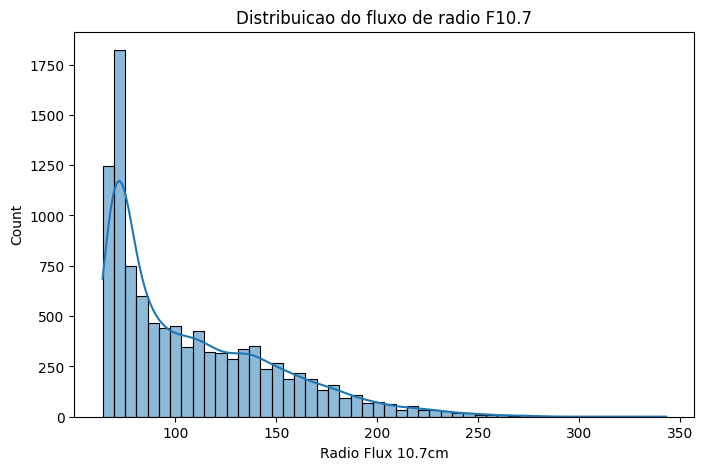

In [8]:
# distribuicao do alvo
sns.histplot(data=df, x='Radio Flux 10.7cm', kde=True)
plt.title('Distribuicao do fluxo de radio F10.7')
plt.show()

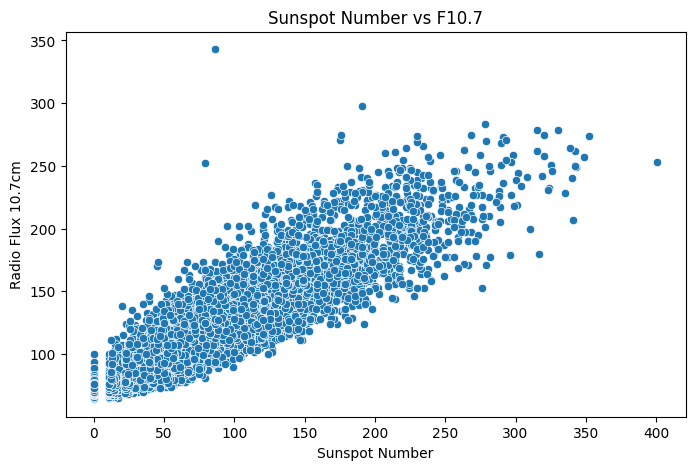

In [9]:
# relacao com o numero de manchas
sns.scatterplot(x='Sunspot Number', y='Radio Flux 10.7cm', data=df)
plt.title('Sunspot Number vs F10.7')
plt.show()

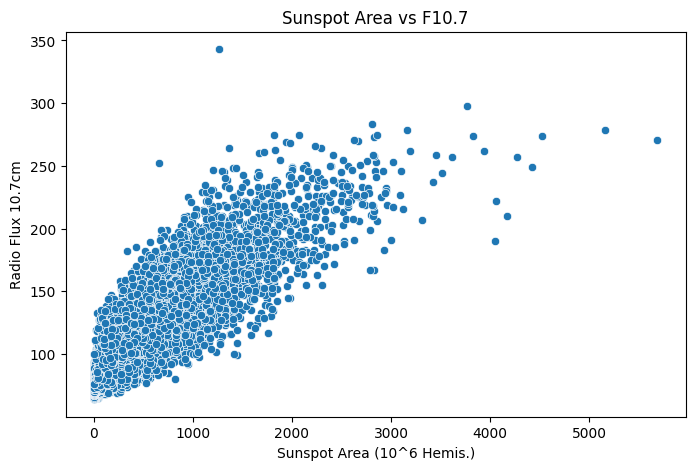

In [10]:
# relacao com a area de manchas
sns.scatterplot(x='Sunspot Area (10^6 Hemis.)', y='Radio Flux 10.7cm', data=df)
plt.title('Sunspot Area vs F10.7')
plt.show()

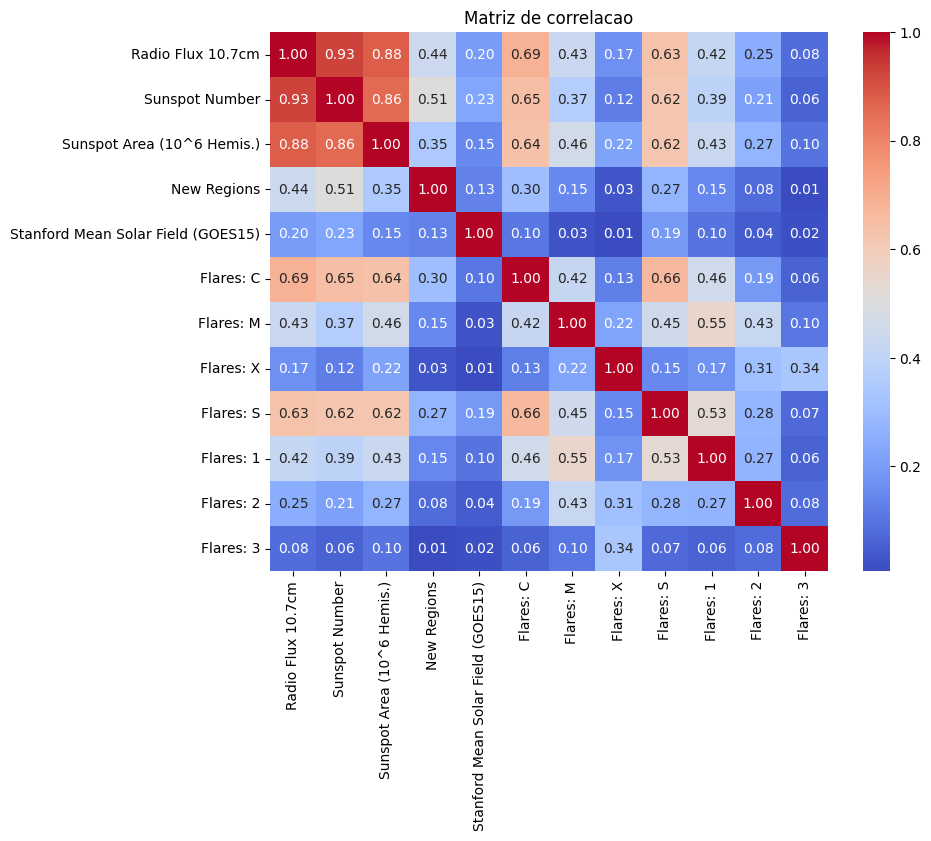

In [11]:
# correlacao entre as variaveis
corr = df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlacao')
plt.show()

O numero de manchas tem correlacao de ~0,93 com o F10.7, e a area de manchas ~0,88.
Isso ja era esperado: as duas medem a mesma atividade solar por caminhos diferentes.

Isso e importante para interpretar o resultado: como existe um preditor muito ligado ao
alvo, e natural que os modelos cheguem a um R2 alto. Nao e o modelo "trapaceando", e o
fenomeno fisico sendo bem capturado pelos indices. Vamos manter essas variaveis e comentar
esse ponto na conclusao.

## 6. Separacao X e y

In [12]:
X = df.drop(columns='Radio Flux 10.7cm')
y = df['Radio Flux 10.7cm']

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)

Shape de X: (10239, 11)
Shape de y: (10239,)


## 7. Holdout (treino / teste)

Separamos 80% para treino e 20% para teste. O modelo aprende no treino e e avaliado
em dados que nao viu.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Treino:', X_train.shape, y_train.shape)
print('Teste :', X_test.shape, y_test.shape)

Treino: (8191, 11) (8191,)
Teste : (2048, 11) (2048,)


## 8. Padronizacao

Regressao Linear e principalmente KNN sao sensiveis a escala das variaveis (o KNN usa
distancia). Por isso padronizamos com `StandardScaler` (media 0, desvio 1).

O scaler e ajustado **so no treino** e depois aplicado no teste, para nao vazar informacao.

A arvore de decisao nao precisa de escala (ela trabalha com cortes em cada variavel),
entao para ela vamos usar os dados originais.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. Funcao de avaliacao

Funcao auxiliar para calcular as metricas de regressao e juntar tudo numa tabela.

In [15]:
def avaliar_regressao(y_true, y_pred, nome_modelo='modelo'):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame({
        'modelo': [nome_modelo],
        'MAE': [mae],
        'RMSE': [rmse],
        'R2': [r2]
    })

## 10. Treinando os modelos

Vamos treinar tres algoritmos vistos na disciplina e comparar:

- Regressao Linear
- KNN Regressor
- Arvore de Decisao

In [16]:
# Regressao Linear (dados padronizados)
lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
pred_lin = lin.predict(X_test_scaled)

# KNN (dados padronizados)
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
pred_knn = knn.predict(X_test_scaled)

# Arvore de Decisao (dados originais)
tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

In [17]:
resultados = pd.concat([
    avaliar_regressao(y_test, pred_lin, 'Regressao Linear'),
    avaliar_regressao(y_test, pred_knn, 'KNN (k=5)'),
    avaliar_regressao(y_test, pred_tree, 'Arvore (max_depth=6)')
], ignore_index=True)

resultados

,modelo,MAE,RMSE,R2
0,Regressao Linear,8.928070,13.049724,0.903691
1,KNN (k=5),9.800684,14.953279,0.873545
2,Arvore (max_depth=6),9.076692,13.507564,0.896815


Como interpretar:

- **MAE**: erro medio absoluto, na mesma unidade do F10.7. Quanto o modelo erra em media.
- **RMSE**: parecido com o MAE, mas penaliza mais os erros grandes.
- **R2**: quanto da variacao do alvo o modelo conseguiu explicar (1 = perfeito).

## 11. Ajuste de hiperparametros e analise de overfitting/underfitting

Aqui testamos diferentes valores dos principais hiperparametros e comparamos o desempenho
no **treino** e no **teste**. Quando o modelo vai muito bem no treino e mal no teste,
temos overfitting. Quando vai mal nos dois, underfitting.

### 11.1 KNN - variando o numero de vizinhos (k)

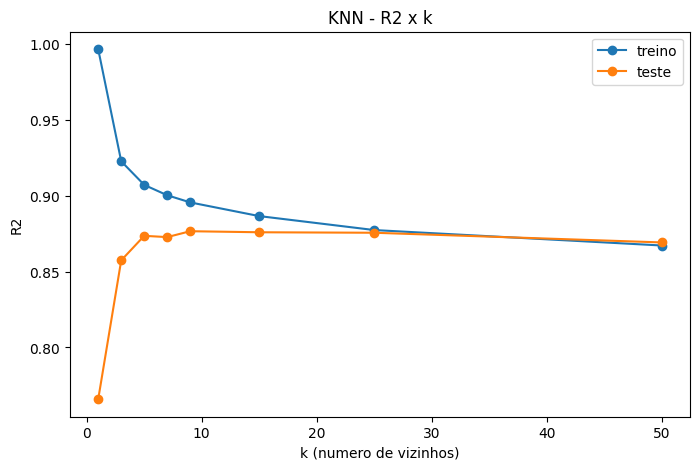

In [18]:
ks = [1, 3, 5, 7, 9, 15, 25, 50]
r2_treino_knn = []
r2_teste_knn = []

for k in ks:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    r2_treino_knn.append(r2_score(y_train, m.predict(X_train_scaled)))
    r2_teste_knn.append(r2_score(y_test, m.predict(X_test_scaled)))

plt.plot(ks, r2_treino_knn, marker='o', label='treino')
plt.plot(ks, r2_teste_knn, marker='o', label='teste')
plt.xlabel('k (numero de vizinhos)')
plt.ylabel('R2')
plt.title('KNN - R2 x k')
plt.legend()
plt.show()

Com `k=1` o modelo decora o treino (R2 perto de 1) mas vai pior no teste -> overfitting.
Conforme k aumenta, o modelo fica mais suave; se k ficar grande demais ele perde detalhe
e comeca a subajustar.

### 11.2 Arvore - variando a profundidade maxima

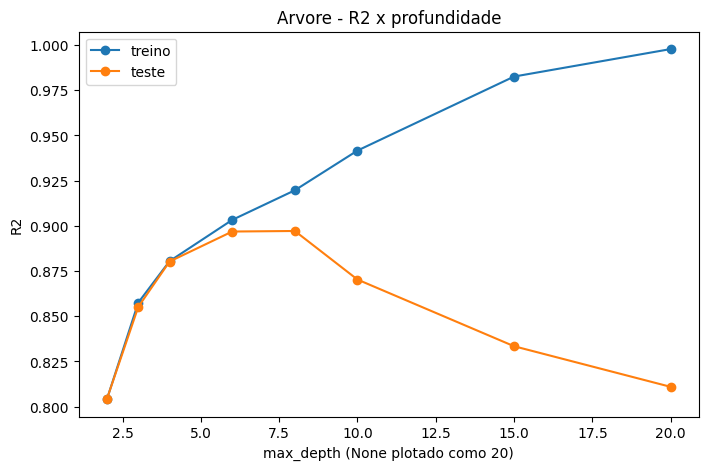

In [19]:
profundidades = [2, 3, 4, 6, 8, 10, 15, None]
r2_treino_tree = []
r2_teste_tree = []

for d in profundidades:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    r2_treino_tree.append(r2_score(y_train, m.predict(X_train)))
    r2_teste_tree.append(r2_score(y_test, m.predict(X_test)))

eixo_x = [d if d is not None else 20 for d in profundidades]
plt.plot(eixo_x, r2_treino_tree, marker='o', label='treino')
plt.plot(eixo_x, r2_teste_tree, marker='o', label='teste')
plt.xlabel('max_depth (None plotado como 20)')
plt.ylabel('R2')
plt.title('Arvore - R2 x profundidade')
plt.legend()
plt.show()

A arvore mostra o overfitting de forma bem clara: com profundidade pequena (2) ela
subajusta (treino e teste baixos e parecidos). Aumentando a profundidade, o R2 de treino
sobe ate quase 1, mas o de teste para de melhorar e chega a piorar -> a arvore decora o
treino. Uma profundidade intermediaria (em torno de 6) equilibra os dois.

## 12. Modelo escolhido e interpretacao

A Regressao Linear teve o melhor (ou empatado) R2 e e o modelo mais simples e mais facil
de interpretar, entao vamos usa-la como modelo final.

Como treinamos com dados padronizados, cada coeficiente indica o quanto o F10.7 muda
quando aquela variavel aumenta 1 desvio padrao, mantendo as outras fixas.

In [20]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': lin.coef_
}).sort_values('coef', ascending=False)

coef_df

,feature,coef
0,Sunspot Number,25.318450
1,Sunspot Area (10^6 Hemis.),11.235477
4,Flares: C,4.305774
5,Flares: M,1.481421
6,Flares: X,0.528977
9,Flares: 2,0.363663
3,Stanford Mean Solar Field (GOES15),0.358191
10,Flares: 3,0.272697
2,New Regions,-0.089953
7,Flares: S,-0.151324


## 13. Real vs previsto

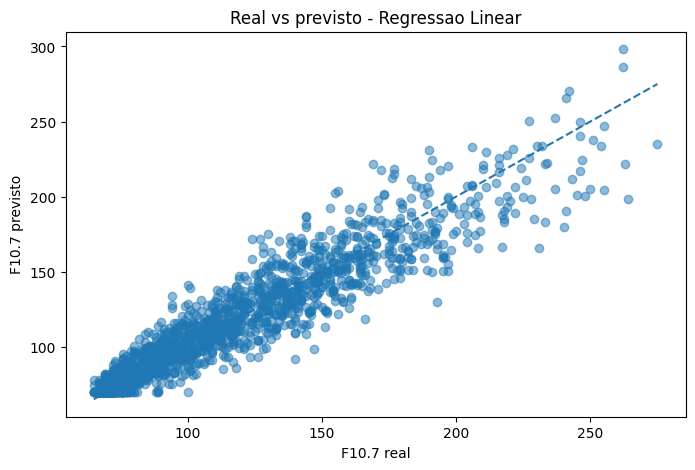

In [21]:
plt.scatter(y_test, pred_lin, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel('F10.7 real')
plt.ylabel('F10.7 previsto')
plt.title('Real vs previsto - Regressao Linear')
plt.show()

## 14. Residuos

Residuo = valor real - valor previsto. Se o modelo for bom, os residuos ficam espalhados
de forma aleatoria em torno de zero, sem padrao.

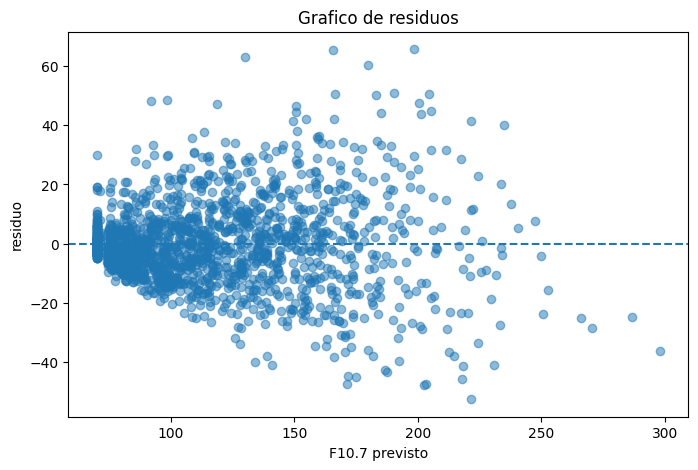

In [22]:
residuos = y_test - pred_lin

plt.scatter(pred_lin, residuos, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.xlabel('F10.7 previsto')
plt.ylabel('residuo')
plt.title('Grafico de residuos')
plt.show()

## 15. Conclusao

- O problema foi prever o fluxo de radio solar F10.7 a partir de outros indices solares.
- Testamos Regressao Linear, KNN e Arvore de Decisao. A Regressao Linear teve o melhor
  desempenho e e a mais interpretavel, por isso foi escolhida como modelo final.
- O R2 alto se explica pela forte relacao entre numero de manchas e F10.7 (correlacao ~0,93),
  o que faz sentido fisicamente: sao formas diferentes de medir a mesma atividade solar.
- A analise de hiperparametros mostrou claramente o overfitting (arvore profunda / KNN com
  k=1) e o underfitting (arvore rasa / k muito grande).
- Aplicacao: prever o F10.7 ajuda a estimar o arrasto atmosferico sobre satelites em orbita
  baixa, o que e relevante para a operacao de constelacoes de satelites na nova economia espacial.